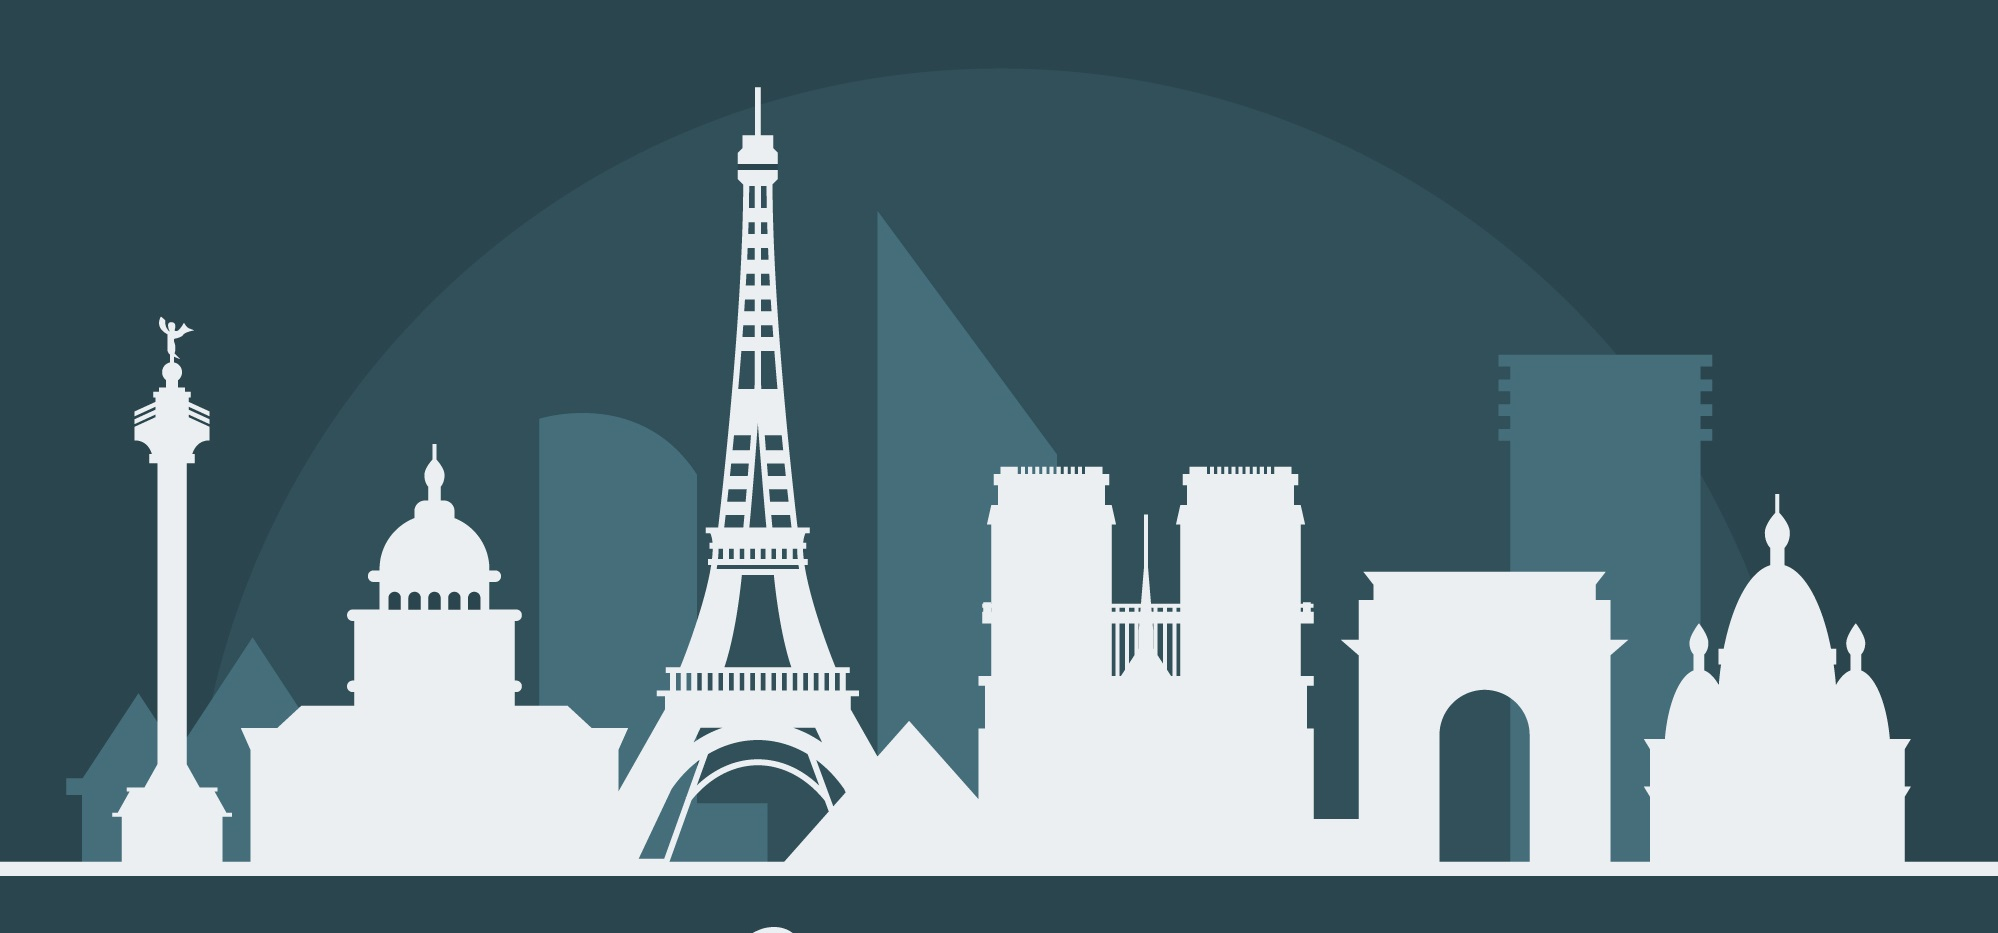

# **✅1.IMPORTING LIBRARIES**
___

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error
import pandas as pd
import numpy as np
import base64
import seaborn as sns
import matplotlib.pyplot as plt
import os
import random
import gc

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from mlxtend.preprocessing import minmax_scaling
from sklearn.metrics import log_loss
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from imblearn.over_sampling import SMOTE
from scipy import stats
import optuna
import xgboost as xgb
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,AdaBoostClassifier, GradientBoostingClassifier, 
                              ExtraTreesClassifier, VotingClassifier,ExtraTreesRegressor,AdaBoostRegressor,GradientBoostingRegressor)
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LassoCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.utils import class_weight
from catboost import CatBoostRegressor
from catboost import CatBoostClassifier
from sklearn.svm import SVR
from sklearn import datasets, linear_model
import lightgbm as lgb
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import GroupKFold
from sklearn.model_selection import KFold
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.signal import argrelmin
from scipy.stats import skew
from scipy import stats


pd.set_option('display.max_columns', None)   

from sklearn.model_selection import train_test_split

import eli5
from eli5.sklearn import PermutationImportance
import time

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense,BatchNormalization,Dropout
from tensorflow.keras import utils
import tensorflow_addons as tfa
import keras_tuner
from kerastuner.tuners import RandomSearch, Hyperband, BayesianOptimization
import pandas as pd
from tensorflow import keras
from tensorflow.keras import layers
from kerastuner.tuners import RandomSearch
from kerastuner import HyperParameters, Objective

# **✅ 2.LOADING DATASETS AND SET UP TOOLS**
___

In [ ]:
test = pd.read_csv('/kaggle/input/playground-series-s3e6/test.csv')
test.drop("id",axis=1,inplace=True)
test['adv_val'] =  0

train = pd.read_csv('/kaggle/input/playground-series-s3e6/train.csv')
train.drop("id",axis=1,inplace=True)
train['adv_val'] =  1

original = pd.read_csv('/kaggle/input/paris-housing-price-prediction/ParisHousing.csv')
original['adv_val'] =  2

sample = pd.read_csv('/kaggle/input/playground-series-s3e6/sample_submission.csv')

In [ ]:
sets={'train':train,'test':test,'original':original}

In [ ]:
def dropping_duplicates(data):
    data.drop_duplicates(inplace = True)
    
for n in {'train':train,'original':original}:
    print(f"\033[0;33;40m A number of duplicated rows in {n} is {sets[n].duplicated().sum()}, they were dropped \033[0;30;0m")
    dropping_duplicates(sets[n])

In [ ]:
########################
### General Settings ###
########################

gpu_switch = False

###############################
### RepeatedStratifiedKFold ###
###############################

n_splits = 5
n_repeats =2
sm=SMOTE(sampling_strategy='minority')
#cv = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats = n_repeats, random_state=2023)
cv = RepeatedKFold(n_splits=n_splits, n_repeats = n_repeats, random_state=2023)
#cv = GroupKFold(n_splits=n_splits)

########################
### Define Weights   ###
########################

weights = {0: 0.5009553158705701, 1: 262.19354838709677}

In [ ]:
###############################################
### The function for step-by-step analyzing ###
###############################################
def LGBM_get_score(X,y):
    param = {'metric': 'rmse', 
            'early_stopping_round': 300, 
            'n_estimators': 5000}
    results=[]
    for i,(train_index, test_index) in enumerate(cv.split(X, y)):
        train_X, valid_X = X.iloc[train_index], X.iloc[test_index]
        train_y, valid_y = y.iloc[train_index], y.iloc[test_index]
        model = lgb.LGBMRegressor(**param).fit(train_X,train_y,
                                            eval_set=[(valid_X,valid_y)],
                                            callbacks=[lgb.log_evaluation(period=0, show_stdv=False)]) 
        result=np.sqrt(mean_squared_error(valid_y,model.predict(valid_X))) 
        results.append(result)
        print (f'\033[0;33;40m Step#{i} Auc result = {result} \033[0;30;0m')
    print (f'\033[0;35;40m Final LGBM Result = {sum(results)/len(results)} \033[0;30;0m')

In [ ]:
###############################################
### The function for step-by-step analyzing ###
###############################################
def RF_get_score(X,y):
    param = {'n_jobs':-1}
    results=[]
    for i,(train_index, test_index) in enumerate(cv.split(X, y)):
        train_X, valid_X = X.iloc[train_index], X.iloc[test_index]
        train_y, valid_y = y.iloc[train_index], y.iloc[test_index]
        model = RandomForestRegressor(**param).fit(train_X,train_y) 
        result=np.sqrt(mean_squared_error(valid_y,model.predict(valid_X))) 
        results.append(result)
        print (f'\033[0;33;40m Step#{i} Auc result = {result} \033[0;30;0m')
    print (f'\033[0;35;40m Final LGBM Result = {sum(results)/len(results)} \033[0;30;0m')

In [ ]:
#########################################################################
### The function for data distribution analysis between two datasets  ###
#########################################################################

def viz_comp (data1,data2,title):
    n_bins = 50
    histplot_hyperparams = {
        'kde':True,
        'alpha':0.4,
        'stat':'percent',
        'bins':n_bins
    }
    cols=num_cols
    fig, ax = plt.subplots(len(cols)//3+1,3, figsize=(20, 20))
    ax = ax.flatten()

    for i, column in enumerate(cols):
        sns.histplot(
            data1[column], label='Train',
            ax=ax[i], color='green', **histplot_hyperparams)

    for i, column in enumerate(cols):
        sns.histplot(
            data2[column], label='Train',
            ax=ax[i], color='red', **histplot_hyperparams)
    ax[0].set_title(title, fontstyle='normal',size=25)

In [ ]:
##############################
### Permutation importance ###
##############################

def permutation_importance(model,X,y):
    permute = PermutationImportance(model,random_state=2023,n_iter =10,cv=5).fit(X, y)
    eli5.show_weights(permute, feature_names = X.columns.tolist(),top=50)
    values = dict(zip(list(train.columns),list(permute.feature_importances_)))
    sorted_dict = {}
    sorted_keys = sorted(values, key=values.get)
    for w in sorted_keys:
        sorted_dict[w] = values[w]

# **✅3.MISS INFORMATION**
___

In [ ]:
def miss_values_check(data,n):
    print(f'\033[0;33;40m A number of NaN values in {n} is {data.isnull().sum().sum()} \033[0;30;0m')
    if data.isnull().sum().sum() >0:
        sns.heatmap(data.isnull())
for n in sets:
    miss_values_check(sets[n],n)

# **✅4.PREPROCESSING**
___

# **✅4.1 ENCODING AND IMPUTING**
___

In [ ]:
num_cols = ['squareMeters','numberOfRooms','floors','cityPartRange','numPrevOwners',
            'made','basement','attic','garage','hasGuestRoom','cityCode'
            ]
cat_cols = ['hasYard','hasPool','isNewBuilt','hasStormProtector','hasStorageRoom',]
drop_col = []

train.drop(drop_col,axis=1,inplace=True)
test.drop(drop_col,axis=1,inplace=True)
original.drop(drop_col,axis=1,inplace=True)

In [ ]:
num_imp = SimpleImputer(strategy='mean')
cat_imp = SimpleImputer(strategy='most_frequent')
ohe = OneHotEncoder(handle_unknown='ignore',sparse = False,drop="first")

train[num_cols] = pd.DataFrame(num_imp.fit_transform(train[num_cols]),columns=num_cols)
train[cat_cols] = pd.DataFrame(cat_imp.fit_transform(train[cat_cols]),columns=cat_cols)
train_temp=pd.DataFrame(ohe.fit_transform(train[cat_cols]),columns=ohe.get_feature_names_out())
train=pd.concat([train.drop(cat_cols,axis=1),train_temp],axis=1) 

original[num_cols] = pd.DataFrame(num_imp.transform(original[num_cols]),columns=num_cols)
original[cat_cols] = pd.DataFrame(cat_imp.transform(original[cat_cols]),columns=cat_cols)
original_temp=pd.DataFrame(ohe.transform(original[cat_cols]),columns=ohe.get_feature_names_out())
original=pd.concat([original.drop(cat_cols,axis=1),original_temp],axis=1)    

test[num_cols] = pd.DataFrame(num_imp.transform(test[num_cols]),columns=num_cols)
test[cat_cols] = pd.DataFrame(cat_imp.transform(test[cat_cols]),columns=cat_cols)
test_temp=pd.DataFrame(ohe.transform(test[cat_cols]),columns=ohe.get_feature_names_out())
test=pd.concat([test.drop(cat_cols,axis=1),test_temp],axis=1)  

# **✅4.2 ADVERSARIAL VALIDATION**
___

In [ ]:
target='price'

In [ ]:
def adv_validation (data_1,data_2,key):
    X_temp=shuffle(pd.concat([data_1,data_2],ignore_index=True))
    if key == True:
        adv_list = ['adv_val']
    else:
        adv_list = ['adv_val',target]
        
    X_full=X_temp.drop(adv_list,axis=1)
    y_full=X_temp.adv_val
    X_full,y_full=shuffle(X_full,y_full)
    X_full=X_full.reset_index(drop=True)
    y_full=y_full.reset_index(drop=True)
    result = cross_val_score(lgb.LGBMClassifier(n_estimators=200),X_full,y_full,scoring='roc_auc',cv=5).mean()
    return result

In [ ]:
sets_adv_val={'train':train,'original':original}
for one in sets_adv_val:
    print (f'\033[0;33;40m Result between {one} and test = {adv_validation(sets_adv_val[one],test,False)} \033[0;30;0m')

In [ ]:
model = lgb.LGBMClassifier(n_estimators=100)
X=shuffle(pd.concat([original,test],ignore_index=True).drop(['adv_val',target],axis=1),random_state=2023).reset_index(drop=True)
y=shuffle(pd.concat([original,test],ignore_index=True).adv_val,random_state=2023).reset_index(drop=True)
metric='roc_auc'
permute = PermutationImportance(model,random_state=2023,n_iter =10,cv=5,scoring = metric).fit(X, y)
eli5.show_weights(permute, feature_names = X.columns.tolist(),top=50)

In [ ]:
model = lgb.LGBMRegressor(n_estimators=100)
X=shuffle(pd.concat([train]).drop(['adv_val',target],axis=1),random_state=2023).reset_index(drop=True)
y=shuffle(pd.concat([train]).price,random_state=2023).reset_index(drop=True)
metric = 'neg_root_mean_squared_error'
permute = PermutationImportance(model,random_state=2023,n_iter =10,cv=5,scoring=metric).fit(X=X, y=y)
eli5.show_weights(permute, feature_names = X.columns.tolist(),top=50)

In [ ]:
adv_final = adv_validation(train[['squareMeters','adv_val','price']],
                           test[['squareMeters','adv_val']],
                           False)
print (f'\033[0;33;40m Result between train and test = {adv_final} \033[0;30;0m')

In [ ]:
adv_final = adv_validation(train[['squareMeters','price','adv_val']],
                           original[['squareMeters','price','adv_val']],
                           True)
print (f'\033[0;33;40m Result between train and original = {adv_final} \033[0;30;0m')

In [ ]:
train=pd.concat([train,original],ignore_index=True)

In [ ]:
train=train.drop('adv_val',axis=1)
test=test.drop('adv_val',axis=1)
original=original.drop('adv_val',axis=1)

# **✅4.3 ANALYZING DISTRIBUTIONS AND OUTLIERS**
___

In [ ]:
X = train.drop([target],axis=1)
y = train[target]
X,y=shuffle(X,y,random_state=2023)
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

In [ ]:
##########################################
### It is the most valnurable features ###
##########################################
num_cols_outl=['squareMeters']

from sklearn.neighbors import LocalOutlierFactor
cont_FEATURES = num_cols_outl

def plot_outliers(data,target,df, feature, threshold=8):
    mean, std = np.mean(df), np.std(df)
    z_score = np.abs((df-mean) / std)
    good = z_score < threshold
    print(f"\033[0;33;40m Rejection {(~good).sum()} points \033[0;30;0m ")
    visual_scatter = np.random.normal(size=df.size)
    plt.scatter(df[good], visual_scatter[good], s=2, label="Good", color="#4CAF50")
    plt.scatter(df[~good], visual_scatter[~good], s=8, label="Bad", color="#F44336")
    plt.legend(loc='upper right')
    plt.title(feature)
    plt.show();
    data,target = data[good],target[good]
    return data,target

for feature in cont_FEATURES:
    print(feature)
    X,y = plot_outliers(X,y,X[feature], feature)

In [ ]:
###########################
### additional dropping ###
###########################

indexies =X[X['squareMeters']>99999].index
X=X.drop(indexies).reset_index(drop=True) #square meters
y=y.drop(indexies).reset_index(drop=True) #square meters

In [ ]:
X['floors']=X['floors'].apply(lambda x: x if x<1000 else train['floors'].mean())
X['made']=X['made'].apply(lambda x: x if x<2022 else train['made'].mean() )
X['basement']=X['basement'].apply(lambda x: x if x<=10000 else train['basement'].mean() )
test['basement']=test['basement'].apply(lambda x: x if x<=10000 else train['basement'].mean() )
X['attic']=X['attic'].apply(lambda x: x if x<=10000 else train['attic'].mean() )
test['attic']=test['attic'].apply(lambda x: x if x<=10000 else train['attic'].mean() )
X['garage']=X['garage'].apply(lambda x: x if x<=1000 else train['garage'].mean() )
X['cityCode']=X['cityCode'].apply(lambda x: x if x<=100000 else int(train['cityCode'].mean()) )
test['cityCode']=test['cityCode'].apply(lambda x: x if x<=100000 else int(train['cityCode'].mean()) )
X['points']=X['hasYard_1']+X['hasPool_1']+X['isNewBuilt_1']+X['hasStormProtector_1']+X['hasStorageRoom_1']
X.drop(['hasYard_1','hasPool_1','isNewBuilt_1','hasStormProtector_1','hasStorageRoom_1'],axis=1,inplace=True)
test['points']=test['hasYard_1']+test['hasPool_1']+test['isNewBuilt_1']+test['hasStormProtector_1']+test['hasStorageRoom_1']
test.drop(['hasYard_1','hasPool_1','isNewBuilt_1','hasStormProtector_1','hasStorageRoom_1'],axis=1,inplace=True)

In [ ]:
viz_comp(X,test,'X VS Test')

In [ ]:
X=X.reset_index(drop=True)
y=y.reset_index(drop=True)


# **✅4.4 NORMALIZATION AND SCALING**
___

In [ ]:
for n in train.columns:
    print(str(round(skew(train[n]),3)) +" = "+ n)

In [ ]:
def StaSca_transform(X,test):
    StaSca = StandardScaler()
    X[num_cols] = pd.DataFrame(data = StaSca.fit_transform(X[num_cols]),columns = X[num_cols].columns)
    test[num_cols] = pd.DataFrame(data = StaSca.transform(test[num_cols]),columns = test[num_cols].columns)

In [ ]:
def Box_transform(X,test):
    box_cols = ['fixed acidity','volatile acidity','residual sugar',
                 'chlorides','free sulfur dioxide','total sulfur dioxide',
                 'sulphates','alcohol']

    for column in box_cols: 
        X_temp,fitted_lambda = stats.boxcox(X[column]) 
        X[column]=X_temp 
        test_temp = stats.boxcox(test[column],fitted_lambda) 
        test[column]=test_temp

# **✅4.5 PERMUTATION IMPORTANCE.**
___

In [ ]:
def perm_imp(model,data,target):
    X = data.to_numpy().copy()
    y = target.to_numpy().copy()
    permute = PermutationImportance(model,random_state=2023,n_iter =2,cv=10,scoring='neg_root_mean_squared_error').fit(X, y)
    eli5.show_weights(permute, feature_names = data.columns.tolist(),top=50)
    values = dict(zip(list(data.columns),list(permute.feature_importances_)))
    sorted_dict = {}
    sorted_keys = sorted(values, key=values.get)
    for w in sorted_keys:
        sorted_dict[w] = np.round(values[w],3)
    return sorted_dict



# **✅5.MODELING**
___

In [ ]:
########################
### Define Weights   ###
########################

#classes = y.unique()
#weight = class_weight.compute_class_weight(class_weight='balanced', classes=classes, y=y)
#weights = dict(zip(classes, list(weight)))

#######################
### Optuna Settings ###
#######################

optuna_study = True 

optuna_models={'LGBM' : False, 
               'XGB'  : False,
               'CAT'  : False,
               'AB'   : False,
               'GB'   : False,
               'ET'   : False,
               'RF'   : False,
               'LCV'  : False,
               'LR'   : False,
               'KNC'  : False,
               'SVC'  : False,
               'KERAS': False}

#######################
### Finish Settings ###
#######################
finish_set = True

finish_models={'LGBM' : False,
               'XGB'  : True,
               'CAT'  : True,
               'AB'   : False,
               'GB'   : False,
               'ET'   : False,
               'RF'   : True,
               'LCV'  : False,
               'LR'   : False,
               'KNC'  : False,
               'SVC'  : False,
               'KERAS': False}

#####################
### Consolidation ###
#####################
models={}
preds_val={}
preds_test={}

#######################
### X for modelling ###
#######################
X_model=X.copy()
test_model = test.copy()
y_model = y.copy()

# **✅5.1. LGBM**
___

In [ ]:
################
### Settings ###
################
model_name='LGBM'
metric = 'rmse'

In [ ]:
X = X_model
test = test_model
y=y_model

In [ ]:
LGBM_drop_list=[]

In [ ]:
X = X_model.drop(LGBM_drop_list,axis=1)
test = test_model.drop(LGBM_drop_list,axis=1)
y=y_model

In [ ]:
if gpu_switch == "ON":
    method = "gpu"
else:
    method = "cpu"

def objective(trial):
    param = {
     'device': method,
     "metric":trial.suggest_categorical("metric", [metric]), 
     'verbosity': -1,
     'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0),
     'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0),
     'learning_rate': trial.suggest_float('learning_rate', 0.001,0.1),
     'num_leaves': trial.suggest_int('num_leaves', 2, 512),
     'feature_fraction': trial.suggest_float('feature_fraction', 0.4, 1.0),
     'bagging_fraction': trial.suggest_float('bagging_fraction', 0.4, 1.0),
     'early_stopping_round' : trial.suggest_int('early_stopping_round', 300, 300),
     'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
     'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
     'n_estimators' : trial.suggest_int('n_estimators', 100, 5000),
     "subsample":trial.suggest_categorical("subsample", [None]),
     "subsample_freq":trial.suggest_categorical("subsample_freq", [None]),
     "reg_alpha":trial.suggest_categorical("reg_alpha", [None]),
     "colsample_bytree":trial.suggest_categorical("colsample_bytree", [None]),
     "reg_lambda":trial.suggest_categorical("reg_lambda", [None]),
     #'class_weight':weights
             }
    
    results=[]
    n_iterations=[]
    for train_index, test_index in cv.split(X, y):
        train_X, valid_X = X.iloc[train_index], X.iloc[test_index]
        train_y, valid_y = y.iloc[train_index], y.loc[test_index]
        model = lgb.LGBMRegressor(**param).fit(train_X,train_y,
                                            eval_set=[(valid_X,valid_y)],
                                            callbacks=[lgb.log_evaluation(period=0, show_stdv=False)]
                                             )  
        result = np.sqrt(mean_squared_error(valid_y,model.predict(valid_X)))
        results.append(result)
    n=sum(results)/len(results)   
    return n

if  optuna_study == optuna_models[model_name]:
    study = optuna.create_study(pruner=optuna.pruners.HyperbandPruner(),
                                direction='minimize')
    study.optimize(objective, n_trials=10000)
    print('Best trial:', study.best_trial.params)

In [ ]:
params_best= {'metric': 'rmse', 
              #'device': method,
              'lambda_l1': 5.078005150077925, 
              'lambda_l2': 8.766299102360916, 
              'learning_rate': 0.06048918191086229, 
              'num_leaves': 115, 
              'feature_fraction': 0.9843912928216596, 
              'bagging_fraction': 0.9623433158831239, 
              'early_stopping_round': 300, 
              'bagging_freq': 1, 
              'min_child_samples': 40, 
              'n_estimators': 2446, 
              'subsample': None, 
              'subsample_freq': None, 
              'reg_alpha': None, 
              'colsample_bytree': None, 
              'reg_lambda': None}

In [ ]:
if finish_models[model_name] and finish_set:
    results=[]
    for i,(train_index, test_index) in enumerate(cv.split(X, y)):
        j=i//n_splits
        start_time = time.time()
        train_X, valid_X = X.iloc[train_index], X.iloc[test_index]
        train_y, valid_y = y.iloc[train_index], y.iloc[test_index]
        model = lgb.LGBMRegressor(**params_best).fit(train_X,train_y,
                                                eval_set=[(valid_X,valid_y)],
                                                callbacks=[lgb.log_evaluation(period=0, show_stdv=False)])  
        
        models[f'{model_name}_{i}_{j}']=(model)
        preds_val[f'{model_name}_{i}_{j}']=(model.predict(valid_X))
        preds_test[f'{model_name}_{i}_{j}']=(model.predict(test))
        
        result = np.sqrt(mean_squared_error(valid_y,model.predict(valid_X)))
        results.append(result)
        print (f'\033[0;33;40m Step #{i}.' + f"--- {time.time() - start_time}s sec ---" + f"Auc result = {result} \033[0;30;0m")
    print (f'\033[0;35;40m Final LGB Result = {sum(results)/len(results)} \033[0;30;0m')

# **✅5.2. XGB**
___

In [ ]:
################
### Settings ###
################

model_name='XGB'
objective = 'reg:squarederror'

In [ ]:
X = X_model
test = test_model
y=y_model

In [ ]:
perm_imp(xgb.XGBRegressor(),X,y)

In [ ]:
XGB_drop_list=['numPrevOwners','floors']

In [ ]:
X = X_model.drop(XGB_drop_list,axis=1)
test = test_model.drop(XGB_drop_list,axis=1)
y=y_model

In [ ]:
if gpu_switch:
    method = "gpu_hist"
else:
    method = "hist" 
    
def objective(trial):
    param = {  
        'tree_method':method,
        #'objective': objective,
        #'eval_metric': 'auc',
        'lambda': trial.suggest_float('lambda', 0, 10.0),
        'alpha': trial.suggest_float('alpha', 0, 10.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.1,1.0),
        'subsample': trial.suggest_float('subsample', 0.2,1.0),
        'learning_rate': trial.suggest_float('learning_rate', 0.001,0.1),
        'n_estimators': trial.suggest_int('n_estimators', 100,5000),
        'max_depth': trial.suggest_categorical('max_depth', [2,3,4,5,6,7,8,9,10]),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'num_parallel_tree': trial.suggest_int('num_parallel_tree',1,1),
        'early_stopping_rounds':trial.suggest_int('early_stopping_rounds',200,200),
        #'scale_pos_weight':weight[0],
        }
    results=[]
    n_iterations=[]  
    for train_index, test_index in cv.split(X, y):
        train_X, valid_X = X.iloc[train_index], X.iloc[test_index]
        train_y, valid_y = y.iloc[train_index], y.iloc[test_index]
        model = xgb.XGBRegressor(**param).fit(train_X,train_y,
                                      eval_set=[(valid_X,valid_y)],
                                      verbose=0,
     
                                     )  
        result = np.sqrt(mean_squared_error(valid_y,model.predict(valid_X)))
        results.append(result)
    n=sum(results)/len(results) 
    return n

if  optuna_study==optuna_models[model_name]:
    study = optuna.create_study(pruner=optuna.pruners.HyperbandPruner(),
                                direction='minimize')
    study.optimize(objective, n_trials=1000)

In [ ]:
params_best = {'lambda': 9.602360802461654, 
               'alpha': 1.9367021518818865, 
               'colsample_bytree': 0.9489503029564506, 
               'subsample': 0.8719573918366775, 
               'learning_rate': 0.07483177933461031, 
               'n_estimators': 4398,
               'max_depth': 4, 
               'min_child_weight': 2, 
               'num_parallel_tree': 1, 
               'early_stopping_rounds': 200}

In [ ]:
if finish_models[model_name] and finish_set:
    results=[]
    for i,(train_index, test_index) in enumerate(cv.split(X, y)):
        j=i//n_splits
        start_time = time.time()
        train_X, valid_X = X.iloc[train_index], X.iloc[test_index]
        train_y, valid_y = y.iloc[train_index], y.iloc[test_index]
        model = xgb.XGBRegressor(**params_best).fit(train_X,train_y,
                                          eval_set=[(train_X,train_y),(valid_X,valid_y)],
                                          verbose=0)  
        
        models[f'{model_name}_{i}_{j}']=(model)
        preds_val[f'{model_name}_{i}_{j}']=(model.predict(valid_X))
        preds_test[f'{model_name}_{i}_{j}']=(model.predict(test))
        
        result = np.sqrt(mean_squared_error(valid_y,model.predict(valid_X)))
        results.append(result)
        print (f'\033[0;33;40m Step #{i}.' + f"--- {time.time() - start_time}s sec ---" + f"Auc result = {result} \033[0;30;0m")
    print (f'\033[0;35;40m Final XGB Result = {sum(results)/len(results)} \033[0;30;0m')

# **✅5.3. CAT**
___

In [ ]:
################
### Settings ###
################
model_name='CAT'
objective='RMSE', 
metric = 'RMSE'

In [ ]:
X = X_model
test = test_model
y=y_model

In [ ]:
perm_imp(CatBoostRegressor(verbose=0),X,y)

In [ ]:
CAT_drop_list=['numberOfRooms']

In [ ]:
X = X_model.drop(CAT_drop_list,axis=1)
test = test_model.drop(CAT_drop_list,axis=1)
y=y_model

In [ ]:
if gpu_switch == "ON":
    method = "GPU"
else:
    method = "CPU"

def objective(trial):
    param = {
        'task_type':method,
       # "loss_function":trial.suggest_categorical("loss_function", [objective]),
        'eval_metric':trial.suggest_categorical("eval_metric", [metric]) ,
        "rsm":trial.suggest_float("rsm", 0.5, 1),
        'use_best_model':trial.suggest_categorical("use_best_model", [True]) ,
        "iterations":trial.suggest_int("iterations", 100, 4000),
        "learning_rate":trial.suggest_float("learning_rate", 1e-4, 1e-1, log=True),
        "depth":trial.suggest_int("depth", 4, 9),
        "l2_leaf_reg":trial.suggest_float("l2_leaf_reg", 1e-8, 100.0, log=True),
        "bootstrap_type":trial.suggest_categorical("bootstrap_type", ["Bayesian"]),
        "random_strength":trial.suggest_float("random_strength", 1e-8, 10.0, log=True),
        "bagging_temperature":trial.suggest_float("bagging_temperature", 0.0, 10.0),
        "od_type":trial.suggest_categorical("od_type", ["Iter"]),
        "od_wait":trial.suggest_int("od_wait", 200, 200),
       # 'scale_pos_weight':weight[1],
        "verbose":0}
    results=[]
    n_iterations=[]
    for train_index, test_index in cv.split(X, y):
        train_X, valid_X = X.iloc[train_index], X.iloc[test_index]
        train_y, valid_y = y.iloc[train_index], y.iloc[test_index]
        model = CatBoostRegressor(**param).fit(train_X,train_y,
                                            eval_set=[(valid_X,valid_y)],
                                            verbose=0
                                             )  
        result = np.sqrt(mean_squared_error(valid_y,model.predict(valid_X)))
        results.append(result)
    n=sum(results)/len(results)    
    return n

if  optuna_study==optuna_models[model_name]:
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=1000)
    print('Best trial:', study.best_trial.params)

In [ ]:
params_best={'eval_metric': 'RMSE', 
             'rsm': 0.8612419654237979, 
             'use_best_model': True, 
             'iterations': 3012, 
             'learning_rate': 0.04989902557803795, 
             'depth': 7, 
             'l2_leaf_reg': 27.909332711608926, 
             'bootstrap_type': 'Bayesian', 
             'random_strength': 1.9029390626401702e-05, 
             'bagging_temperature': 0.19703737765580503, 
             'od_type': 'Iter', 
             'od_wait': 200}

In [ ]:
if finish_models[model_name] and finish_set:
    results=[]
    for i,(train_index, test_index) in enumerate(cv.split(X, y)):
        j=i//n_splits
        start_time = time.time()
        train_X, valid_X = X.iloc[train_index], X.iloc[test_index]
        train_y, valid_y = y.iloc[train_index], y.iloc[test_index]
        model = CatBoostRegressor(**params_best).fit(train_X,train_y,
                                            eval_set=[(valid_X,valid_y)],
                                            verbose=0)  
        
        models[f'{model_name}_{i}_{j}']=(model)
        preds_val[f'{model_name}_{i}_{j}']=(model.predict(valid_X))
        preds_test[f'{model_name}_{i}_{j}']=(model.predict(test))
        
        result = np.sqrt(mean_squared_error(valid_y,model.predict(valid_X)))
        results.append(result)
        print (f'\033[0;33;40m Step #{i}.' + f"--- {time.time() - start_time}s sec ---" + f"Auc result = {result} \033[0;30;0m")
    print (f'\033[0;35;40m Final CAT Result = {sum(results)/len(results)} \033[0;30;0m')

In [ ]:
sample['price'] = sum(preds_test.values())/(n_splits*n_repeats)
sample.to_csv(f'{model_name}.csv', index=False)

# **✅5.4. AB**
___

In [ ]:
################
### Settings ###
################
model_name='AB'

In [ ]:
AB_drop_list=[]

In [ ]:
X = X_model.drop(AB_drop_list,axis=1)
test = test_model.drop(AB_drop_list,axis=1)
y=y_model

In [ ]:
def objective(trial):   
    param = {
        'criterion':trial.suggest_categorical("criterion", ['entropy']), 
        'n_estimators':trial.suggest_int("n_estimators", 10, 250,step=5),
        'n_jobs':trial.suggest_categorical("n_jobs", [-1]),
        'class_weight':trial.suggest_categorical("class_weight", [weights]),
        'verbose':trial.suggest_categorical("verbose", [0]),
        'max_depth':trial.suggest_int("max_depth", 3, 8,step=1),
        'min_samples_split':trial.suggest_int("min_samples_split", 2, 4,step=1),
        'min_samples_leaf':trial.suggest_int("min_samples_leaf", 1, 4,step=1),
        'max_features':trial.suggest_categorical("max_features", ['sqrt','log2']),
        'verbose':0}
    results=[]
    for train_index, test_index in cv.split(X, y):
        train_X, valid_X = X.iloc[train_index], X.iloc[test_index]
        train_y, valid_y = y.iloc[train_index], y.iloc[test_index]
        model = ExtraTreesRegressor(**param).fit(train_X,train_y)  
        result = roc_auc_score(valid_y,(model.predict(valid_X)))
        results.append(result)
    n=sum(results)/len(results)        
    return n

if optuna_study == optuna_models[model_name]:
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=1000)
    print('Best trial:', study.best_trial.params)

In [ ]:
params_best = {}

In [ ]:
if finish_models[model_name] and finish_set:
    results=[]
    for i,(train_index, test_index) in enumerate(cv.split(X, y)):
        j=i//n_splits
        start_time = time.time()
        train_X, valid_X = X.iloc[train_index], X.iloc[test_index]
        train_y, valid_y = y.iloc[train_index], y.iloc[test_index]
        model = AdaBoostRegressor(**params_best).fit(train_X,train_y)  
        
        models[f'{model_name}_{i}_{j}']=(model)
        preds_val[f'{model_name}_{i}_{j}']=(model.predict(valid_X))
        preds_test[f'{model_name}_{i}_{j}']=(model.predict(test))
        
        result = np.sqrt(mean_squared_error(valid_y,model.predict(valid_X)))
        results.append(result)
        print (f'\033[0;33;40m Step #{i}.' + f"--- {time.time() - start_time}s sec ---" + f"Auc result = {result} \033[0;30;0m")
    print (f'\033[0;35;40m Final AB Result = {sum(results)/len(results)} \033[0;30;0m')

# **✅5.5. GB**
___

In [ ]:
################
### Settings ###
################
model_name='GB'
objective= 0
metric =0

In [ ]:
GB_drop_list=[]

In [ ]:
X = X_model.drop(GB_drop_list,axis=1)
test = test_model.drop(GB_drop_list,axis=1)
y=y_model

In [ ]:
def objective(trial):   
    param = {
        'criterion':trial.suggest_categorical("criterion", ['entropy']), 
        'n_estimators':trial.suggest_int("n_estimators", 10, 250,step=5),
        'n_jobs':trial.suggest_categorical("n_jobs", [-1]),
        'class_weight':trial.suggest_categorical("class_weight", [weights]),
        'verbose':trial.suggest_categorical("verbose", [0]),
        'max_depth':trial.suggest_int("max_depth", 3, 8,step=1),
        'min_samples_split':trial.suggest_int("min_samples_split", 2, 4,step=1),
        'min_samples_leaf':trial.suggest_int("min_samples_leaf", 1, 4,step=1),
        'max_features':trial.suggest_categorical("max_features", ['sqrt','log2']),
        'verbose':0}
    results=[]
    for train_index, test_index in cv.split(X, y):
        train_X, valid_X = X.iloc[train_index], X.iloc[test_index]
        train_y, valid_y = y.iloc[train_index], y.iloc[test_index]
        model = ExtraTreesRegressor(**param).fit(train_X,train_y)  
        result = roc_auc_score(valid_y,(model.predict(valid_X)))
        results.append(result)
    n=sum(results)/len(results)        
    return n

if optuna_study == optuna_models[model_name]:
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=1000)
    print('Best trial:', study.best_trial.params)

In [ ]:
params_best = {}

In [ ]:
if finish_models[model_name] and finish_set:
    results=[]
    for i,(train_index, test_index) in enumerate(cv.split(X, y)):
        j=i//n_splits
        start_time = time.time()
        train_X, valid_X = X.iloc[train_index], X.iloc[test_index]
        train_y, valid_y = y.iloc[train_index], y.iloc[test_index]
        model = GradientBoostingRegressor(**params_best).fit(train_X,train_y)  
        
        models[f'{model_name}_{i}_{j}']=(model)
        preds_val[f'{model_name}_{i}_{j}']=(model.predict(valid_X))
        preds_test[f'{model_name}_{i}_{j}']=(model.predict(test))
        
        result = np.sqrt(mean_squared_error(valid_y,model.predict(valid_X)))
        results.append(result)
        print (f'\033[0;33;40m Step #{i}.' + f"--- {time.time() - start_time}s sec ---" + f"Auc result = {result} \033[0;30;0m")
    print (f'\033[0;35;40m Final GB Result = {sum(results)/len(results)} \033[0;30;0m')

# **✅5.6. ET**
___

In [ ]:
################
### Settings ###
################
model_name='ET'
objective= 0
metric =0

In [ ]:
ET_drop_list=[]

In [ ]:
X = X_model.drop(ET_drop_list,axis=1)
test = test_model.drop(ET_drop_list,axis=1)
y=y_model

In [ ]:
def objective(trial):   
    param = {
        'criterion':trial.suggest_categorical("criterion", ['entropy']), 
        'n_estimators':trial.suggest_int("n_estimators", 10, 250,step=5),
        'n_jobs':trial.suggest_categorical("n_jobs", [-1]),
        'class_weight':trial.suggest_categorical("class_weight", [weights]),
        'verbose':trial.suggest_categorical("verbose", [0]),
        'max_depth':trial.suggest_int("max_depth", 3, 8,step=1),
        'min_samples_split':trial.suggest_int("min_samples_split", 2, 4,step=1),
        'min_samples_leaf':trial.suggest_int("min_samples_leaf", 1, 4,step=1),
        'max_features':trial.suggest_categorical("max_features", ['sqrt','log2']),
        'verbose':0}
    results=[]
    for train_index, test_index in cv.split(X, y):
        train_X, valid_X = X.iloc[train_index], X.iloc[test_index]
        train_y, valid_y = y.iloc[train_index], y.iloc[test_index]
        model = ExtraTreesRegressor(**param).fit(train_X,train_y)  
        result = roc_auc_score(valid_y,(model.predict(valid_X)))
        results.append(result)
    n=sum(results)/len(results)        
    return n

if optuna_study == optuna_models[model_name]:
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=1000)
    print('Best trial:', study.best_trial.params)

In [ ]:
params_best = {}

In [ ]:
if finish_models[model_name] and finish_set:
    results=[]
    for i,(train_index, test_index) in enumerate(cv.split(X, y)):
        j=i//n_splits
        start_time = time.time()
        train_X, valid_X = X.iloc[train_index], X.iloc[test_index]
        train_y, valid_y = y.iloc[train_index], y.iloc[test_index]
        model = ExtraTreesRegressor(**params_best).fit(train_X,train_y)  
        
        models[f'{model_name}_{i}_{j}']=(model)
        preds_val[f'{model_name}_{i}_{j}']=(model.predict(valid_X))
        preds_test[f'{model_name}_{i}_{j}']=(model.predict(test))
        
        result = np.sqrt(mean_squared_error(valid_y,model.predict(valid_X)))
        results.append(result)
        print (f'\033[0;33;40m Step #{i}.' + f"--- {time.time() - start_time}s sec ---" + f"Auc result = {result} \033[0;30;0m")
    print (f'\033[0;35;40m Final ET Result = {sum(results)/len(results)} \033[0;30;0m')

# **✅5.7. RF**
___

In [ ]:
################
### Settings ###
################
model_name='RF'
objective= 'squared_error'

In [ ]:
X = X_model
test = test_model
y=y_model

In [ ]:
perm_imp(RandomForestRegressor(),X,y)

In [ ]:
RF_drop_list=['hasGuestRoom','attic','basement','points','garage']

In [ ]:
X = X_model.drop(RF_drop_list,axis=1)
test = test_model.drop(RF_drop_list,axis=1)
y=y_model

In [ ]:
def objective(trial):   
    param = {
      #  'criterion':trial.suggest_categorical("criterion", [objective]), 
        'n_estimators':trial.suggest_int("n_estimators", 10, 300,step=5),
        'n_jobs':trial.suggest_categorical("n_jobs", [-1]),
        #'class_weight':trial.suggest_categorical("class_weight", [weights]),
        'verbose':trial.suggest_categorical("verbose", [0]),
        'max_depth':trial.suggest_int("max_depth", 3, 12,step=1),
        'min_samples_split':trial.suggest_int("min_samples_split", 2, 4,step=1),
        'min_samples_leaf':trial.suggest_int("min_samples_leaf", 1, 4,step=1),
       # 'max_features':trial.suggest_categorical("max_features", ['sqrt','log2']),
        'verbose':0}
    results=[]
    for train_index, test_index in cv.split(X, y):
        train_X, valid_X = X.iloc[train_index], X.iloc[test_index]
        train_y, valid_y = y.iloc[train_index], y.iloc[test_index]
        model = RandomForestRegressor(**param).fit(train_X,train_y)  
        result = np.sqrt(mean_squared_error(valid_y,model.predict(valid_X)))
        results.append(result)
    n=sum(results)/len(results)        
    return n

if optuna_study == optuna_models[model_name]:
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=1000)
    print('Best trial:', study.best_trial.params)

In [ ]:
params_best={'n_estimators': 145, 
             'n_jobs': -1, 
             'verbose': 0, 
             #'max_depth': 15, 
             'min_samples_split': 2, 
             'min_samples_leaf': 2}

In [ ]:
if finish_models[model_name] and finish_set:
    results=[]
    for i,(train_index, test_index) in enumerate(cv.split(X, y)):
        j=i//n_splits
        start_time = time.time()
        train_X, valid_X = X.iloc[train_index], X.iloc[test_index]
        train_y, valid_y = y.iloc[train_index], y.iloc[test_index]
        model = RandomForestRegressor(**params_best).fit(train_X,train_y)  
        
        models[f'{model_name}_{i}_{j}']=(model)
        preds_val[f'{model_name}_{i}_{j}']=((model.predict(valid_X)))
        preds_test[f'{model_name}_{i}_{j}']=((model.predict(test)))
        
        result = np.sqrt(mean_squared_error(valid_y,model.predict(valid_X)))
        results.append(result)
        print (f'\033[0;33;40m Step #{i}.' + f"--- {time.time() - start_time}s sec ---" + f"Auc result = {result} \033[0;30;0m")
    print (f'\033[0;35;40m Final RF Result = {sum(results)/len(results)} \033[0;30;0m')

In [ ]:
sample['price'] =  sum(preds_test.values())/(10)
sample.to_csv(f'{model_name}.csv', index=False)

# **✅5.8. LCV**
___

In [ ]:
LCV_drop_list=[]

In [ ]:
################
### Settings ###
################
model_name='LCV'
objective= 'squared_error'
metric =0

In [ ]:
X = X_model.drop(LCV_drop_list,axis=1)
test = test_model.drop(LCV_drop_list,axis=1)
y=y_model
#X =X.to_numpy()
#test = test.to_numpy()
#y = y_model.to_numpy()

In [ ]:
def objective(trial):
    print("START__________________________________")       
    param = {
        'precompute':"auto",
        'fit_intercept':True,
        'normalize':False,
        'max_iter':1000,
        'verbose':False,
        'eps':1e-04,
        'cv':cv,
        'n_alphas':1000,
        'n_jobs':8
        }
    results=[]
    n_iterations=[]
    for train_index, test_index in cv.split(X, y):
        train_X, valid_X = X.iloc[train_index], X.iloc[test_index]
        train_y, valid_y = y.iloc[train_index], y.iloc[test_index]
        model = LassoCV(**params).fit(train_X,train_y,
                                            eval_set=[(valid_X,valid_y)],
                                            verbose=0
                                             )  
        result = roc_auc_score(valid_y,((model.predict_proba(valid_X)[:,1])))
        results.append(result)
    print("Average n_ite=" + str(i))
    n=sum(results)/len(results)
    print(n)
    print("FIIINISH__________________________________\n")    
            
    return n

if optuna_study == optuna_models[model_name]:
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=1000)
    print('Best trial:', study.best_trial.params)

In [ ]:
 params_best = {}

In [ ]:
if finish_models[model_name] and finish_set:
    results=[]
    for i,(train_index, test_index) in enumerate(cv.split(X, y)):
        j=i//n_splits
        start_time = time.time()
        train_X, valid_X = X.iloc[train_index], X.iloc[test_index]
        train_y, valid_y = y.iloc[train_index], y.iloc[test_index]
       
        model = linear_model.LassoCV(*params_best).fit(train_X,train_y)  
        
        models[f'{model_name}_{i}_{j}']=(model)
        preds_val[f'{model_name}_{i}_{j}']=(model.predict(valid_X))
        preds_test[f'{model_name}_{i}_{j}']=(model.predict(test))
        
        result = np.sqrt(mean_squared_error(valid_y,model.predict(valid_X)))
        results.append(result)
        print (f'\033[0;33;40m Step #{i}.' + f"--- {time.time() - start_time}s sec ---" + f"Auc result = {result} \033[0;30;0m")
    print (f'\033[0;35;40m Final LCV Result = {sum(results)/len(results)} \033[0;30;0m')

# **✅5.9. LR**
___

In [ ]:
################
### Settings ###
################
model_name='LR'
objective= 'squared_error'
metric = 0

In [ ]:
LR_drop_list=[]

In [ ]:
X = X_model.drop(LR_drop_list,axis=1)
test = test_model.drop(LR_drop_list,axis=1)
y = y_model

In [ ]:
if gpu_switch == "ON":
    method = "GPU"
else:
    method = "CPU"

def objective(trial):
    print("START__________________________________")       
    param = {
       # 'precompute':"auto",
       # 'fit_intercept':True,
       # 'normalize':False,
        #'max_iter':1000,
        #'verbose':False,
        #'eps':1e-04,
       # 'cv':cv,
        #'n_alphas':1000,
        #'task_type':method,
       # "#loss_function":trial.suggest_categorical("loss_function", ["Logloss"]),
        
       # 'penalty':trial.suggest_categorical("penalty", ['l1', 'l2', 'elasticnet', 'none']) ,
       # 'solver':trial.suggest_categorical("solver", ['lbfgs','newton-cg','liblinear','sag','saga']) ,
        "max_iter":trial.suggest_int("max_iter", 100, 4000), 
        #"C":trial.suggest_float("C", 1e-4, 4, log=True),
        'class_weight':{0:1,1:1}
    }
        
    results=[]
    for train_index, test_index in cv.split(X, y):
        train_X, valid_X = X.iloc[train_index], X.iloc[test_index]
        train_y, valid_y = y.iloc[train_index], y.iloc[test_index]
        model = LogisticRegression(**param).fit(train_X,train_y)
        result = roc_auc_score(valid_y,((model.predict_proba(valid_X)[:,1])))
        results.append(result)
    n=sum(results)/len(results)       
    return n

if  optuna_study==optuna_models['LR']:
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=1000)
    print('Best trial:', study.best_trial.params)

In [ ]:
params_best = {}

In [ ]:
if finish_models[model_name] and finish_set:
    results=[]
    for i,(train_index, test_index) in enumerate(cv.split(X, y)):
        j=i//n_splits
        start_time = time.time()
        train_X, valid_X = X.iloc[train_index], X.iloc[test_index]
        train_y, valid_y = y.iloc[train_index], y.iloc[test_index]
       
        model = LinearRegression(**params_best).fit(train_X,train_y)
        
        models[f'{model_name}_{i}_{j}']=(model)
        preds_val[f'{model_name}_{i}_{j}']=(model.predict(valid_X))
        preds_test[f'{model_name}_{i}_{j}']=(model.predict(test))
        
        result = np.sqrt(mean_squared_error(valid_y,model.predict(valid_X)))
        results.append(result)
        print (f'\033[0;33;40m Step #{i}.' + f"--- {time.time() - start_time}s sec ---" + f"Auc result = {result} \033[0;30;0m")
    print (f'\033[0;35;40m Final LR Result = {sum(results)/len(results)} \033[0;30;0m')

# **✅5.10. KNC**
___

In [ ]:
################
### Settings ###
################
model_name='KNC'
objective=0
metric =0

In [ ]:
KNC_drop_list=[]

In [ ]:
X = X_model.drop(KNC_drop_list,axis=1)
test = test_model.drop(KNC_drop_list,axis=1)

In [ ]:
def objective(trial):
    param = {
    'n_neighbors' : trial.suggest_int("n_neighbors", 1, 500),
    'leaf_size' : trial.suggest_int("leaf_size", 1, 500),
    'weights' : trial.suggest_categorical("weights", ['uniform', 'distance']),
    'p' : trial.suggest_categorical("p", [1, 2, 3, 4, 5]),
    'metric' : trial.suggest_categorical("metric", ['euclidean', 'manhattan', 'minkowski'])}
 
    results=[]
    n_iterations=[]
    for train_index, test_index in cv.split(X, y):
        train_X, valid_X = X.iloc[train_index], X.iloc[test_index]
        train_y, valid_y = y.iloc[train_index], y.iloc[test_index]
        
        #train_X,train_y = sm.fit_resample(train_X,train_y)
        
        model = KNeighborsClassifier(**param).fit(train_X,train_y)  
        result = np.sqrt(mean_squared_error(valid_y,model.predict(valid_X)))
        results.append(result)
    n=sum(results)/len(results)
    print(n)
    print("FIIINISH__________________________________\n")    
            
    return n

if  optuna_study==optuna_models[model_name]:
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=1000)
    print('Best trial:', study.best_trial.params)

In [ ]:
params_KNC_best={'n_neighbors': 77, 
                 'leaf_size': 343, 
                 'weights': 'distance', 
                 'p': 3, 
                 'metric': 'manhattan'}

In [ ]:
if finish_models[model_name] == finish_set:
    results=[]
    n_iterations=[]
    for i,(train_index, test_index) in enumerate(cv.split(X, y)):
        j=i//n_splits
        start_time = time.time()
        train_X, valid_X = X.iloc[train_index], X.iloc[test_index]
        train_y, valid_y = y.iloc[train_index], y.iloc[test_index]
        
        model = KNeighborsRegressor().fit(train_X,train_y)  
        
        models[f'{model_name}_{i}_{j}']=(model)
        preds_val[f'{model_name}_{i}_{j}']=(model.predict(valid_X))
        preds_test[f'{model_name}_{i}_{j}']=(model.predict(test))
        
        result = np.sqrt(mean_squared_error(valid_y,model.predict(valid_X)))
        results.append(result)
        print (f'\033[0;33;40m Step #{i}.' + f"--- {time.time() - start_time}s sec ---" + f"Auc result = {result} \033[0;30;0m")
    print (f'\033[0;35;40m Final KNC Result = {sum(results)/len(results)} \033[0;30;0m')

# **✅5.11. SVC**
___

In [ ]:
################
### Settings ###
################
model_name='SVC'
objective= 0
metric =0

In [ ]:
SVC_drop_list=[]

In [ ]:
X = X_model.drop(SVC_drop_list,axis=1)
test = test_model.drop(SVC_drop_list,axis=1)
StaSca_transform(X,test)

In [ ]:
def objective(trial):
    param= {
            'kernel': trial.suggest_categorical("kernel", ['linear', 'rbf', 'poly']), 
            'gamma': trial.suggest_categorical("gamma", [0.001, 0.01, 0.1, 1, 10, 100]),
            'C': trial.suggest_categorical("C", [0.001, 0.01, 0.1, 1,10,100,1000]),
            'degree': trial.suggest_categorical("degree", [0, 1, 2, 3, 4, 5, 6]),
            'probability':trial.suggest_categorical("probability", [True]),
    }
    results=[]
    for train_index, test_index in cv.split(X, y):
        train_X, valid_X = X.iloc[train_index], X.iloc[test_index]
        train_y, valid_y = y.iloc[train_index], y.iloc[test_index]
              
        model = SVC(**param).fit(train_X,train_y)  
        result = np.sqrt(mean_squared_error(valid_y,model.predict(valid_X)))
        results.append(result)
    n=sum(results)/len(results)
    return n

if  optuna_study==optuna_models[model_name]:
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=1000)
    print('Best trial:', study.best_trial.params)

In [ ]:
params_best= {'kernel': 'poly', 
              'degree': 3, 
              'C':100, 
              'epsilon': 0.01
                   }

In [ ]:
if finish_models[model_name] == finish_set:
    results=[]
    for i,(train_index, test_index) in enumerate(cv.split(X, y)):
        start_time = time.time()
        train_X, valid_X = X.iloc[train_index], X.iloc[test_index]
        train_y, valid_y = y.iloc[train_index], y.iloc[test_index]
        model = SVR(**params_best).fit(train_X,train_y)  
                
        models[f'{model_name}_{i}_{j}']=(model)
        preds_val[f'{model_name}_{i}_{j}']=(model.predict(valid_X))
        preds_test[f'{model_name}_{i}_{j}']=(model.predict(test))
        
        result = np.sqrt(mean_squared_error(valid_y,model.predict(valid_X)))
        results.append(result)
        print (f'\033[0;33;40m Step #{i}.' + f"--- {time.time() - start_time}s sec ---" + f"Auc result = {result} \033[0;30;0m")
    print (f'\033[0;35;40m Final LGB Result = {sum(results)/len(results)} \033[0;30;0m')

# **✅5.12. Keras**
___

In [ ]:
################
### Settings ###
################
model_name='KERAS'
objective= 0
metric =0

In [ ]:
KERAS_drop_list=[]

In [ ]:
X = X_model.drop(KERAS_drop_list,axis=1)
test = test_model.drop(KERAS_drop_list,axis=1)

In [ ]:
X =X.to_numpy()
test = test.to_numpy()
y = y_model.to_numpy()
input_shape = [X.shape[1]]

In [ ]:
opt = tf.optimizers.Adam(learning_rate=0.001)
reduce_lr_loss = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_auc', 
                                                      factor=0.8, 
                                                      patience=3, 
                                                      verbose=0,
                                                      min_delta=0.0001 ,
                                                      min_lr=0.000001, 
                                                      mode='max')

early_stopping = keras.callbacks.EarlyStopping(patience=8,
                                               verbose=0,
                                               min_delta=0.0001,
                                               monitor="val_auc",
                                               mode='max',
                                               restore_best_weights=True)

def get_model(trial):
    opt = tf.optimizers.Adam(learning_rate=0.001)
    reduce_lr_loss = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_auc', 
                                                          factor=0.8, 
                                                          patience=3, 
                                                          verbose=0,
                                                          min_delta=0.0001 ,
                                                          min_lr=0.000001, 
                                                          mode='max')

    early_stopping = keras.callbacks.EarlyStopping(patience=8,
                                                   verbose=0,
                                                   min_delta=0.0001,
                                                   monitor="val_auc",
                                                   mode='max',
                                                   restore_best_weights=True)
    model = keras.Sequential()
    activation=trial.suggest_categorical("activation_type_is_", ['relu','selu'])
    model.add(layers.BatchNormalization(input_shape = [X.shape[1]]))
    
    for i in np.arange(0,trial.suggest_int("num_layers", 1, 6)):
        model.add(layers.Dense(units = trial.suggest_int("units_"+str(i+1), 32, 512, step =32),
                               activation=activation))
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(trial.suggest_float("drop_"+str(i+1), 0.05, 0.25,step=0.05))) 
   
    model.add(layers.Dense(1, activation='sigmoid'))
    model.compile(
    optimizer=opt,
    loss=tfa.losses.SigmoidFocalCrossEntropy(alpha=0.80, gamma=2.0),
    #loss='binary_crossentropy',
    metrics=['AUC'])  
    weights_before_update=model.get_weights()
    
    preds=[]
    results=[]
    i=0
    for train_index, test_index in (cv.split(X, y)):
        opt = tf.optimizers.Adam(learning_rate=0.001)
        reduce_lr_loss = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_auc', 
                                                              factor=0.8, 
                                                              patience=5, 
                                                              verbose=0,
                                                              min_delta=0.0001 ,
                                                              min_lr=0.000001, mode='max')

        early_stopping = keras.callbacks.EarlyStopping(patience=10,
                                                       min_delta=0.0001,
                                                       monitor="val_auc",
                                                       mode='max',
                                                       restore_best_weights=True)
    
        i+=1
        start_time=time.time()
        train_X, valid_X = X[train_index], X[test_index]
        train_y, valid_y = y[train_index], y[test_index]
        history = model.fit(
            train_X,train_y,
            validation_data=(valid_X,valid_y),
            batch_size=512*20,
            epochs=200,
            class_weight = weights,
        callbacks=[early_stopping,
                   reduce_lr_loss],
        verbose=0)
        
        pred = (model.predict(valid_X))
        preds.append(pred)
        result = roc_auc_score(valid_y,pred)
        
        results.append(result)
        model.set_weights(weights_before_update)
        n=sum(results)/len(results)
        from keras import backend as K 
        K.clear_session()
    return n

In [ ]:
if  optuna_study==optuna_models[model_name]:
    study = optuna.create_study(direction='minimize')
    study.optimize(get_model, n_trials=1000)
    print('Best trial:', study.best_trial.params)

In [ ]:
opt = tf.optimizers.Adam(learning_rate=0.001)


def get_model():
    model = keras.Sequential([
            layers.BatchNormalization(input_shape = [X.shape[1]]),
            layers.Dense(288,activation='selu'),
            layers.BatchNormalization(),
            layers.Dropout(0.2),        
            layers.Dense(320,activation='selu'),
            layers.BatchNormalization(),
            layers.Dropout(0.2),
            layers.Dense(320,activation='selu'),
            layers.BatchNormalization(),
            layers.Dropout(0.2),
            layers.Dense(64,activation='selu'),
            layers.BatchNormalization(),
            layers.Dropout(0.05),
            layers.Dense(32,activation='selu'),
            layers.BatchNormalization(),
            layers.Dropout(0.05),  
            layers.Dense(1,activation='sigmoid'),
    ])
    model.compile(
    optimizer=opt,
       # tf.keras.losses.mean_squared_error
    #loss=tfa.losses.SigmoidFocalCrossEntropy(alpha=0.1, gamma=3),
    loss=tf.keras.losses.MeanSquaredError(reduction="auto", name="mean_squared_error"),
    #metrics=['AUC']
    )  
    
    return model

In [ ]:
gpu_devices = tf.config.experimental.list_physical_devices('GPU')
for device in gpu_devices:
    tf.config.experimental.set_memory_growth(device, True)

In [ ]:
if finish_models[model_name] == finish_set:
    preds=[]
    results=[]
    predicts=pd.DataFrame()
    for i,(train_index, test_index) in enumerate(cv.split(X, y)):
        opt = tf.optimizers.Adam(learning_rate=0.001)
        reduce_lr_loss = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_auc', 
                                                              factor=0.8, 
                                                              patience=5, 
                                                              verbose=0,
                                                              min_delta=0.0001 ,
                                                              min_lr=0.000001, mode='max')

        early_stopping = keras.callbacks.EarlyStopping(patience=30,
                                                       min_delta=0.0001,
                                                       monitor="val_auc",
                                                       mode='max',
                                                       restore_best_weights=True)

        start_time = time.time()
        train_X, valid_X = X[train_index], X[test_index]
        train_y, valid_y = y[train_index], y[test_index]
        model = get_model()
        history = model.fit(
            train_X,train_y,
            validation_data=(valid_X,valid_y),
            batch_size=512*10,
            epochs=400,
            class_weight = weights,
            callbacks=[early_stopping,reduce_lr_loss],
        verbose=1)
        pred = (model.predict(valid_X))
        pred_test = (model.predict(test))
        preds.append(pred)
        predicts[i]=pd.DataFrame(pred_test)
        preds_val[f'{model_name}_{i}_{j}']=model.predict(valid_X).reshape(1,-1)[0]
        preds_test[f'{model_name}_{i}_{j}']=model.predict(test).reshape(1,-1)[0]
        result = round(roc_auc_score(valid_y,pred),4)
        print (f'\033[0;33;40m Step #{i}.' + f"--- {time.time() - start_time}s sec ---" + f"Auc result = {result} \033[0;30;0m")
        results.append(result)
    print (f'\033[0;35;40m Final KERAS result = {(sum(results)/len(results))} \033[0;30;0m')

# **✅ 6. ENSEMBLING (STACKING)**
___

In [ ]:
for n in preds_val:
    preds_val[n]=np.rint(preds_val[n])

In [ ]:
stack_preds=[]
key_model= list(preds_val.keys())[0].split("_")[0]
key_last = list(preds_val.keys())[-1]

for step_model in np.arange(0,n_repeats,1):
    key_model= list(preds_val.keys())[0].split("_")[0]
    temp_0 = pd.DataFrame()
    temp_1 = pd.DataFrame()
    for step_pred in preds_val:
        key = int(step_pred.split("_")[2])
        if key == step_model and step_pred.split("_")[0]==key_model:
            temp_1=pd.concat([temp_1,pd.DataFrame(preds_val[step_pred])],axis=0)

        else:
            if key != step_model:
                next

            else:
                temp_0=pd.concat([temp_0,temp_1],axis=1)
                key_model=step_pred.split("_")[0]
                temp_1=pd.DataFrame()
                temp_1=pd.concat([temp_1,pd.DataFrame(preds_val[step_pred])],axis=0)
    if step_pred==key_last:
        temp_0=pd.concat([temp_0,temp_1],axis=1)

    stack_preds.append(temp_0.reset_index(drop=True))

In [ ]:
for n in preds_test:
    preds_test[n]=np.rint(preds_test[n])

In [ ]:
stack_tests=[]
key_model= list(preds_test.keys())[0].split("_")[0]
key_last = list(preds_test.keys())[-1]

for step_model in np.arange(0,n_repeats,1):
    key_model= list(preds_test.keys())[0].split("_")[0]
    print(step_model)
    temp_0 = pd.DataFrame()
    temp_1 = pd.DataFrame()
    for step_pred in preds_test:
        key = int(step_pred.split("_")[2])
        if key == step_model and step_pred.split("_")[0]==key_model:
            temp_1=pd.concat([temp_1,pd.DataFrame(preds_test[step_pred])],axis=1)

        else:
            if key != step_model:
                next

            else:
                temp_1=temp_1.mean(axis=1)
                temp_0=pd.concat([temp_0,temp_1],axis=1)
            
                key_model=step_pred.split("_")[0]
                temp_1=pd.DataFrame()
                temp_1=pd.concat([temp_1,pd.DataFrame(preds_test[step_pred])],axis=1)
    if step_pred==key_last:
        temp_1=temp_1.mean(axis=1)
        temp_0=pd.concat([temp_0,temp_1],axis=1)

    stack_tests.append(temp_0.reset_index(drop=True))

In [ ]:
stack_targets=[]
for step_model in np.arange(0,n_repeats,1):
    temp=pd.DataFrame()
    for i,(train_index, test_index) in enumerate(cv.split(X, y)):
        key = i//n_splits
        train_X, valid_X = X[train_index], X[test_index]
        train_y, valid_y = y[train_index], y[test_index]
        if step_model == key:
            temp=pd.concat([temp,pd.DataFrame(valid_y)],axis=0)
    stack_targets.append(temp.reset_index(drop=True))

In [ ]:
params_best= {'early_stopping_round':100, 
              'n_estimators':5000}

In [ ]:
results=[]
predicts=pd.DataFrame()
for step_model in np.arange(0,n_repeats,1):
    print(step_model)
    X_stack = stack_preds[step_model].to_numpy()
    test_stack = stack_tests[step_model].to_numpy()
    y_stack = stack_targets[step_model][0].to_numpy()
    for i,(train_index, test_index) in enumerate(cv.split(X, y)):
        temp=pd.DataFrame()
        train_X, valid_X = X_stack[train_index], X_stack[test_index]
        train_y, valid_y = y_stack[train_index], y_stack[test_index]
        model = lgb.LGBMRegressor(**params_best).fit(train_X,train_y,
                                                eval_set=[(valid_X,valid_y)],
                                                callbacks=[lgb.log_evaluation(period=0, show_stdv=False)],
                                                 )  
        result = np.sqrt(mean_squared_error(valid_y,(model.predict(valid_X))))
        results.append(result)
        print (f'\033[0;33;40m Step #{i}.' + f"--- {time.time() - start_time}s seconds ---" + f"Auc result = {result} \033[0;30;0m")
        predict = model.predict(test_stack)
        temp[i]=predict
    predicts[step_model]=temp.mean(axis=1)

print (f'\033[0;35;40m Final LGB Result = {sum(results)/len(results)} \033[0;30;0m')

In [ ]:
sample['price'] = predicts.mean(axis=1)
sample.to_csv('Ensemble(Stacking).csv', index=False)